In [1]:
!nvidia-smi
%matplotlib inline

Sun Apr 12 17:41:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100                    On  |   00000000:06:00.0 Off |                    0 |
| N/A   33C    P0             67W /  700W |       0MiB /  95830MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
from helper_functions_testing import (
    batch_generate_responses_qwen3,
    get_judgments_from_responses,
    run_experiment,
    retrieve_results,
    prepare_test_prompts,
    obtain_results_without)
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
import pandas as pd
import json
import re
import numpy as np
from typing import List, Optional, Dict, Any
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from tqdm import tqdm
import torch

### Loading verified examples (UNDER_gold)

In [4]:
verified_examples = "../Data/UNDER_gold.csv"
df_verified_examples = pd.read_csv(verified_examples)

### General launching commands and code

In [ ]:
# Using sglang to run the larger model

"""
module load 2023
module load CUDA/12.4.0
source ~/sglang-venv-2/bin/activate
huggingface-cli login



# 创建所有必要的目录
mkdir -p /scratch-local/yhuang/sglang_cache
mkdir -p /scratch-local/yhuang/huggingface_cache
mkdir -p /scratch-local/yhuang/torch_cache
mkdir -p /scratch-local/yhuang/cuda_cache
mkdir -p /scratch-local/yhuang/xdg_cache
mkdir -p /scratch-local/yhuang/tmp
mkdir -p /scratch-local/yhuang/logs

# 设置所有相关环境变量
export SGLANG_CACHE_DIR=/scratch-local/yhuang/sglang_cache
export TRANSFORMERS_CACHE=/scratch-local/yhuang/huggingface_cache
export HF_HOME=/scratch-local/yhuang/huggingface_cache
export HF_DATASETS_CACHE=/scratch-local/yhuang/huggingface_cache/datasets
export TORCH_HOME=/scratch-local/yhuang/torch_cache
export CUDA_CACHE_PATH=/scratch-local/yhuang/cuda_cache
export XDG_CACHE_HOME=/scratch-local/yhuang/xdg_cache
export TMPDIR=/scratch-local/yhuang/tmp
export TEMP=/scratch-local/yhuang/tmp
export TMP=/scratch-local/yhuang/tmp
export SGLANG_LOG_DIR=/scratch-local/yhuang/logs

# launching
huggingface-cli login
CUDA_VISIBLE_DEVICES=0,1,2,3 python -m sglang.launch_server --port 7501 --model-path meta-llama/Llama-3.3-70B-Instruct --tensor-parallel-size 4
"""

In [5]:
system_prompt = """
You are an expert analyst. Your task is to analyze and determine whether an input user query is "fully specified" or "underspecified".

"""

task_FS_UND = """
Analyze the following input user query:

{"query": "TARGET"}

Please provide your analysis in the following JSON format:

{"query": "TARGET", "reasoning": "[YOUR_DETAILED_REASONING]", "judgment": "[fully specified/underspecified]"}
"""

#### Llama 3.2

In [7]:
from huggingface_hub import login
login()

In [8]:
import os
print("HF_HOME:", os.environ.get("HF_HOME"))
print("HF_DATASETS_CACHE:", os.environ.get("HF_DATASETS_CACHE"))
print("HF_HUB_CACHE:", os.environ.get("HF_HUB_CACHE"))
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"

# 可选：确保没被错误地关掉进度条
os.environ.pop("HF_HUB_DISABLE_PROGRESS_BARS", None)

HF_HOME: /scratch-local/yhuang/huggingface_cache
HF_DATASETS_CACHE: /scratch-local/yhuang/huggingface_cache/datasets
HF_HUB_CACHE: /scratch-local/yhuang/huggingface_cache/hub


In [9]:
llama_3_2_3B = "meta-llama/Llama-3.2-3B-Instruct"
# Load model directly
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained(llama_3_2_3B, padding_side='left')
model = AutoModelForCausalLM.from_pretrained(llama_3_2_3B)

# 将模型移到可用设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

Loading checkpoint shards: 100%|██████████| 2/2 [00:07<00:00,  3.97s/it]


cuda


In [10]:
def batch_generate_responses_llama(prompts, system_prompt=system_prompt,
                                  temperature=0.7, max_new_tokens=32768, batch_size=5):
    """
    批量生成Llama模型的回复

    参数:
        prompts: 字符串列表，每个字符串是一个提示词
        system_prompt: 系统提示词
        max_new_tokens: 生成的最大token数，默认为512
        batch_size: 每批处理的提示词数量，默认为4

    返回:
        生成的回复列表，与prompts列表对应
    """
    # 设置padding token
    tokenizer.pad_token = tokenizer.eos_token

    responses = []

    # 按批次处理
    for i in tqdm(range(0, len(prompts), batch_size)):
        batch_prompts = prompts[i:i+batch_size]
        batch_texts = []

        # 为每个提示词准备输入文本
        for prompt in batch_prompts:
            messages = [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": prompt}
            ]
            # Llama模型使用apply_chat_template自动应用正确的模板
            text = tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True
            )
            batch_texts.append(text)

        # 批量编码输入
        model_inputs = tokenizer(batch_texts, return_tensors="pt", padding=True, truncation=True).to(model.device)

        # 生成回复
        with torch.no_grad():
            generated_ids = model.generate(
                **model_inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=temperature,
                top_p=0.9,
                repetition_penalty=1.2
            )

        # 分离输入和输出的tokens
        batch_responses = []
        for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids):
            response_ids = output_ids[len(input_ids):]
            response = tokenizer.decode(response_ids, skip_special_tokens=True)
            batch_responses.append(response)

        responses.extend(batch_responses)

    return responses

def run_experiment_llama(input_prompts, test_df):
  output = batch_generate_responses_llama(input_prompts)
  df = test_df.copy()
  df['model_response'] = output
  processed_judgments = get_judgments_from_responses(output)
  df['model_pred'] = processed_judgments

  return df

In [11]:
test_prompts = prepare_test_prompts(df_verified_examples, task_FS_UND)
print(test_prompts[0])

Start preparing prompts...
# Testing data points: 150
Generation complete: 150 prompts
Average prompt length: 331 bytes (~82 tokens)

Analyze the following input user query:

{"query": "When was the first world war broke out?"}

Please provide your analysis in the following JSON format:

{"query": "When was the first world war broke out?", "reasoning": "[YOUR_DETAILED_REASONING]", "judgment": "[fully specified/underspecified]"}



In [12]:
test_df = run_experiment_llama(test_prompts, df_verified_examples)
test_df

100%|██████████| 30/30 [02:34<00:00,  5.16s/it]

Respond content: {"query": "When was the first world war broke out?", "reasoning": [
    {
      "token": "first",
      "type": "entity"
    },
    {
      "token": "world",
      "type": "entity"
    },
    {
      ...
Respond content: {"query": "When does the movie dog days come out?", "reasoning": ["The query lacks specificity regarding the date, year, or release platform (theatrical, streaming, DVD). The word'movie' could refer t...
Respond content: {"query": "When is a new season of fairy tail coming out?", "reasoning": [
"The query contains specific information about a show (Fairy Tail), but lacks details regarding its release date, time frame,...
Respond content: {"query": "The son told Robert that Brian shouted at him. Who did Brian shout at?", "reasoning": [
"This sentence contains a subordinate clause with multiple possible interpretations, indicating that ...


,Unnamed: 0,request,gold_judgment,direct_source,category,reasoning,original_annotation,model_response,model_pred
0,1118,When was the first world war broke out?,underspecified,AmbigNQ,Undetermined perspective or granularity,The phrase “broke out” can be interpreted from...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","{""query"": ""When was the first world war broke ...",error
1,5585,Who sings the song i will try to fix you?,underspecified,AmbigNQ,Undetermined perspective or granularity,The question allows multiple granularities: it...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","{""query"": ""Who sings the song i will try to fi...",underspecified
2,9330,Who is the head of the nation in india?,underspecified,AmbigNQ,Undetermined perspective or granularity,The question can refer to the role or title of...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","{""query"": ""Who is the head of the nation in in...",underspecified
3,9602,Moss is an example of which type of plant?,underspecified,AmbigNQ,Undetermined perspective or granularity,The term “type” can refer to different taxonom...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","{""query"": ""Moss is an example of which type of...",underspecified
4,4145,How long can you serve in the house?,underspecified,AmbigNQ,"Undetermined lexicons or references, Undetermi...",The term “house” is referentially ambiguous be...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","{""query"": ""How long can you serve in the house...",underspecified
...,...,...,...,...,...,...,...,...,...
145,1213,Give me a bulleted list of the 5 highest mount...,fully specified,CLAMBER,fully specified,This question is fully specified because it re...,NaN,"{\n ""query"": ""Give me a bulleted list of th...",full
146,2274,Who is the author of the novel Taipei by Tao Lin?,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"{""query"": ""Who is the author of the novel Taip...",fully specified
147,356,What's the average body length of Brania russe...,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"{\n ""query"": ""What's the average body length ...",underspecified
148,294,Is Bolusia capensis a unicellular organism in ...,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"{""query"": ""Is Bolusia capensis a unicellular o...",underspecified


In [13]:
retrieve_results(test_df, "llama_3.2_3B_verified_test")

There are unrecognized labels.


No error found, directly process the data.
                 precision    recall  f1-score   support

fully specified       0.90      0.18      0.30        51
 underspecified       0.70      0.99      0.82        99

       accuracy                           0.71       150
      macro avg       0.80      0.58      0.56       150
   weighted avg       0.77      0.71      0.64       150



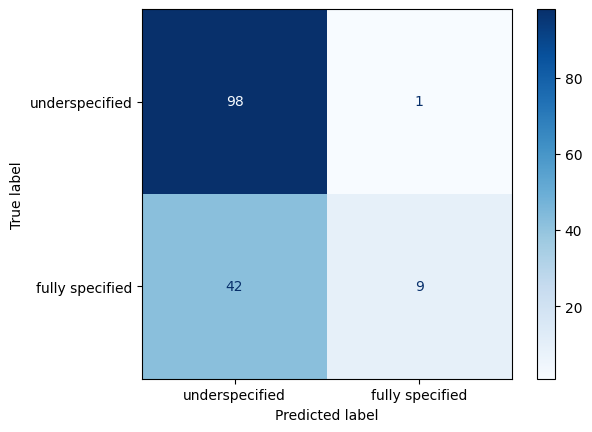

In [14]:
test_df = pd.read_csv("llama_3.2_3B_verified_test_corrected.csv")
retrieve_results(test_df, "llama_3.2_3B_verified_test_corrected")

#### Llama3.3-70B

In [6]:
import os
import time
from tqdm import tqdm
from openai import OpenAI
from concurrent.futures import ThreadPoolExecutor

def batch_generate_responses_llama(prompts, system_prompt=system_prompt,
                  temperature=0.7, max_tokens=32768, batch_size=5,
                  server_url="http://localhost:7501/v1",
                  model_name="meta-llama/Llama-3.3-70B-Instruct"):
    """
    批量生成使用sglang运行的Llama 3.3 70B模型的回复，使用OpenAI API风格

    参数:
        prompts: 字符串列表，每个字符串是一个提示词
        system_prompt: 系统提示词
        temperature: 温度参数，控制随机性，默认为0.7
        max_tokens: 生成的最大token数，默认为512
        batch_size: 并行处理的提示词数量，默认为4
        server_url: SGLang服务器URL，默认为http://localhost:30000/v1
        model_name: 模型名称，默认为meta-llama/Llama-3.3-70B-Instruct
    返回:
        生成的回复列表，与prompts列表对应
    """
    # 初始化OpenAI客户端
    client = OpenAI(
        base_url=server_url,
        api_key="None"  # SGLang不需要API key
    )

    responses = []

    # 辅助函数：处理单个提示词
    def process_prompt(prompt):
        try:
            # 创建消息格式
            messages = [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": prompt}
            ]

            # 发送请求到SGLang服务器
            response = client.chat.completions.create(
                model=model_name,
                messages=messages,
                temperature=temperature,
                max_tokens=max_tokens,
            )

            # 提取回复文本
            return response.choices[0].message.content
        except Exception as e:
            print(f"处理提示词时出错: {e}")
            return f"错误: {str(e)}"

    # 按批次处理
    for i in tqdm(range(0, len(prompts), batch_size)):
        batch_prompts = prompts[i:i+batch_size]

        # 使用线程池并行处理批次
        with ThreadPoolExecutor(max_workers=batch_size) as executor:
            batch_responses = list(executor.map(process_prompt, batch_prompts))

        responses.extend(batch_responses)

        # 添加短暂延迟，避免可能的速率限制
        time.sleep(0.1)

    return responses

def run_experiment_llama(input_prompts, test_df):
  output = batch_generate_responses_llama(input_prompts)
  df = test_df.copy()
  df['model_response'] = output
  processed_judgments = get_judgments_from_responses(output)
  df['model_pred'] = processed_judgments

  return df

In [7]:
test_prompts = prepare_test_prompts(df_verified_examples, task_FS_UND)
print(test_prompts[0])

Start preparing prompts...
# Testing data points: 150
Generation complete: 150 prompts
Average prompt length: 331 bytes (~82 tokens)

Analyze the following input user query:

{"query": "When was the first world war broke out?"}

Please provide your analysis in the following JSON format:

{"query": "When was the first world war broke out?", "reasoning": "[YOUR_DETAILED_REASONING]", "judgment": "[fully specified/underspecified]"}



In [8]:
test_df = run_experiment_llama(test_prompts, df_verified_examples)
test_df

100%|██████████| 30/30 [02:11<00:00,  4.37s/it]


,Unnamed: 0,request,gold_judgment,direct_source,category,reasoning,original_annotation,model_response,model_pred
0,1118,When was the first world war broke out?,underspecified,AmbigNQ,Undetermined perspective or granularity,The phrase “broke out” can be interpreted from...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","{""query"": ""When was the first world war broke ...",fully specified
1,5585,Who sings the song i will try to fix you?,underspecified,AmbigNQ,Undetermined perspective or granularity,The question allows multiple granularities: it...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","{""query"": ""Who sings the song i will try to fi...",fully specified
2,9330,Who is the head of the nation in india?,underspecified,AmbigNQ,Undetermined perspective or granularity,The question can refer to the role or title of...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","{""query"": ""Who is the head of the nation in in...",fully specified
3,9602,Moss is an example of which type of plant?,underspecified,AmbigNQ,Undetermined perspective or granularity,The term “type” can refer to different taxonom...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","{""query"": ""Moss is an example of which type of...",fully specified
4,4145,How long can you serve in the house?,underspecified,AmbigNQ,"Undetermined lexicons or references, Undetermi...",The term “house” is referentially ambiguous be...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","{""query"": ""How long can you serve in the house...",underspecified
...,...,...,...,...,...,...,...,...,...
145,1213,Give me a bulleted list of the 5 highest mount...,fully specified,CLAMBER,fully specified,This question is fully specified because it re...,NaN,"{""query"": ""Give me a bulleted list of the 5 hi...",fully specified
146,2274,Who is the author of the novel Taipei by Tao Lin?,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"{""query"": ""Who is the author of the novel Taip...",fully specified
147,356,What's the average body length of Brania russe...,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"{""query"": ""What's the average body length of B...",fully specified
148,294,Is Bolusia capensis a unicellular organism in ...,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"{""query"": ""Is Bolusia capensis a unicellular o...",fully specified


No error found, directly process the data.
                 precision    recall  f1-score   support

fully specified       0.52      0.92      0.66        51
 underspecified       0.93      0.56      0.70        99

       accuracy                           0.68       150
      macro avg       0.72      0.74      0.68       150
   weighted avg       0.79      0.68      0.68       150



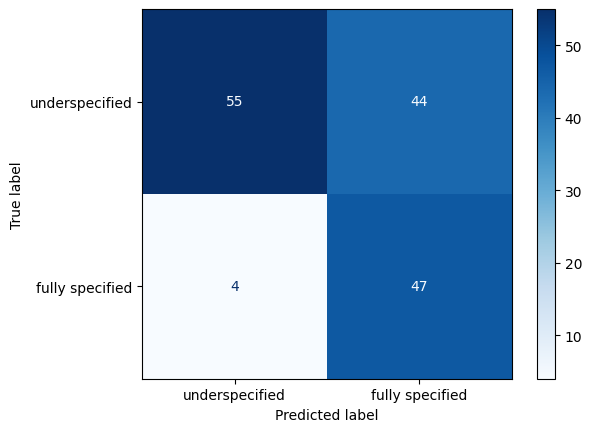

In [9]:
retrieve_results(test_df, "llama_3.3_70B_verified_test")